In [ ]:
!pip install xgboost shap openpyxl -q

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df.head()

Saving BWP300DATA.xlsx to BWP300DATA.xlsx


,Usia,JK,Pendidikan,Riwayat_Keluarga,Persentase nilai identifikasi warna,Tingkat Keparahan,Kemampuan identifikasi Warna,R,I,A,S,E,C,Alat_Bantu_Penglihatan,Penyakit_Mata_Lain,Karier,JobZone,ColorReq,Label
0,17,P,SMA,Tidak,92.86,Normal,33,9,22,8,11,14,12,1,1,Data Analyst,4,Rendah,Direkomendasikan
1,34,L,S1,Ya,78.57,Ringan,27,8,11,9,22,11,8,0,1,Dokter,5,Tinggi,Direkomendasikan
2,24,L,SMA,Tidak,7.14,Berat,14,24,11,8,11,9,13,0,0,Polisi,3,Sedang,Kurang Direkomendasikan
3,26,L,D3,Tidak,92.86,Normal,31,12,10,8,12,12,23,1,0,Akuntan,4,Rendah,Direkomendasikan
4,23,L,S1,Ya,100.00,Normal,33,12,10,8,24,13,10,0,1,Guru,4,Rendah,Direkomendasikan


In [ ]:
print(df.shape)

df.info()

display(df.head())

df.isnull().sum()

(300, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Usia                                 300 non-null    int64  
 1   JK                                   300 non-null    object 
 2   Pendidikan                           300 non-null    object 
 3   Riwayat_Keluarga                     300 non-null    object 
 4   Persentase nilai identifikasi warna  300 non-null    float64
 5   Tingkat Keparahan                    300 non-null    object 
 6   Kemampuan identifikasi Warna         300 non-null    int64  
 7   R                                    300 non-null    int64  
 8   I                                    300 non-null    int64  
 9   A                                    300 non-null    int64  
 10  S                                    300 non-null    int64  
 11  E                     

,Usia,JK,Pendidikan,Riwayat_Keluarga,Persentase nilai identifikasi warna,Tingkat Keparahan,Kemampuan identifikasi Warna,R,I,A,S,E,C,Alat_Bantu_Penglihatan,Penyakit_Mata_Lain,Karier,JobZone,ColorReq,Label
0,17,P,SMA,Tidak,92.86,Normal,33,9,22,8,11,14,12,1,1,Data Analyst,4,Rendah,Direkomendasikan
1,34,L,S1,Ya,78.57,Ringan,27,8,11,9,22,11,8,0,1,Dokter,5,Tinggi,Direkomendasikan
2,24,L,SMA,Tidak,7.14,Berat,14,24,11,8,11,9,13,0,0,Polisi,3,Sedang,Kurang Direkomendasikan
3,26,L,D3,Tidak,92.86,Normal,31,12,10,8,12,12,23,1,0,Akuntan,4,Rendah,Direkomendasikan
4,23,L,S1,Ya,100.00,Normal,33,12,10,8,24,13,10,0,1,Guru,4,Rendah,Direkomendasikan


,0
Usia,0
JK,0
Pendidikan,0
Riwayat_Keluarga,0
Persentase nilai identifikasi warna,0
Tingkat Keparahan,0
Kemampuan identifikasi Warna,0
R,0
I,0
A,0


In [ ]:
df['Label'].value_counts()

,count
Label,
Direkomendasikan,254
Kurang Direkomendasikan,39
Tidak Direkomendasikan,7


In [ ]:
data = df.copy()

label_encoder = {}

categorical_features = [

    'JK',

    'Pendidikan',

    'Riwayat_Keluarga',

    'Tingkat Keparahan',

    'Karier',

    'ColorReq'

]

for col in categorical_features:

    le = LabelEncoder()

    data[col] = le.fit_transform(data[col])

    label_encoder[col] = le


target_encoder = LabelEncoder()

data['Label'] = target_encoder.fit_transform(data['Label'])

In [ ]:
X = data.drop(columns=['Label'])

y = data['Label']

print(X.columns)

Index(['Usia', 'JK', 'Pendidikan', 'Riwayat_Keluarga',
       'Persentase nilai identifikasi warna', 'Tingkat Keparahan',
       'Kemampuan identifikasi Warna', 'R', 'I', 'A', 'S', 'E', 'C',
       'Alat_Bantu_Penglihatan', 'Penyakit_Mata_Lain', 'Karier', 'JobZone',
       'ColorReq'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=123,

    stratify=y

)

In [ ]:
model = XGBClassifier(

    objective='multi:softprob',

    num_class=3,

    eval_metric='mlogloss',

    n_estimators=500,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=3,

    gamma=0,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=123

)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=3, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test,y_pred)

print("Accuracy :",round(acc*100,2),"%")

Accuracy : 98.33 %


In [ ]:
print(

classification_report(

    y_test,

    y_pred,

    target_names=target_encoder.classes_

)

)

                         precision    recall  f1-score   support

       Direkomendasikan       1.00      1.00      1.00        51
Kurang Direkomendasikan       0.89      1.00      0.94         8
 Tidak Direkomendasikan       0.00      0.00      0.00         1

               accuracy                           0.98        60
              macro avg       0.63      0.67      0.65        60
           weighted avg       0.97      0.98      0.98        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


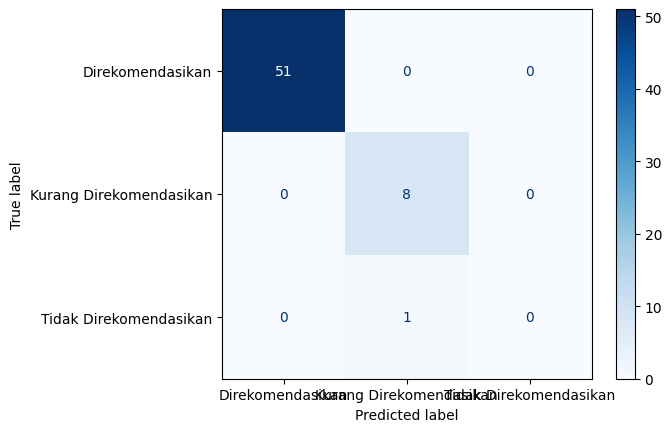

In [ ]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=target_encoder.classes_

)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

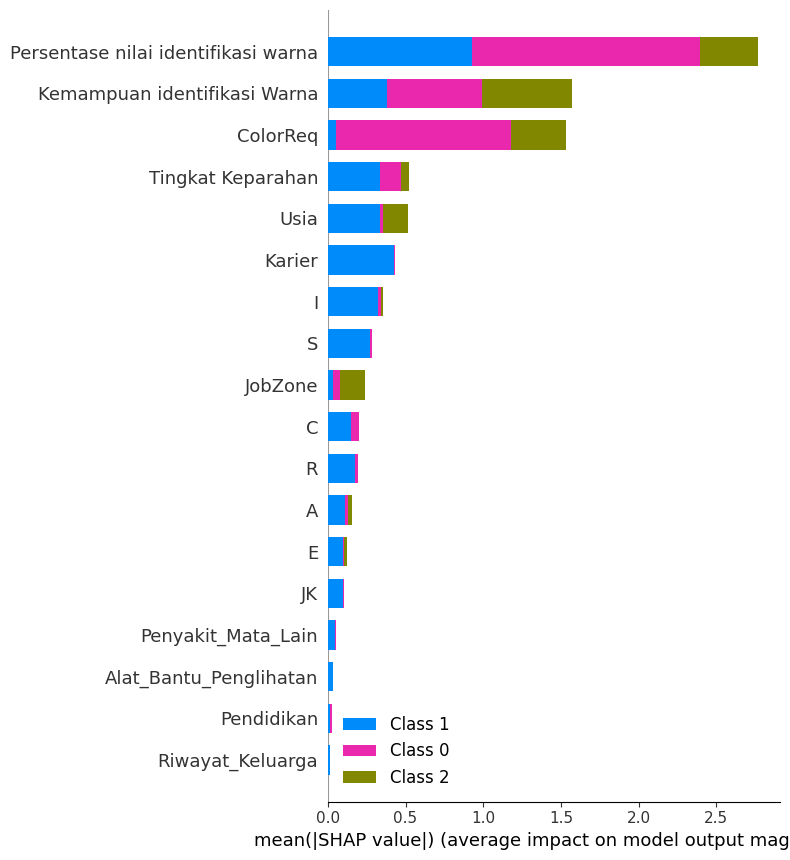

In [ ]:
shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"

)

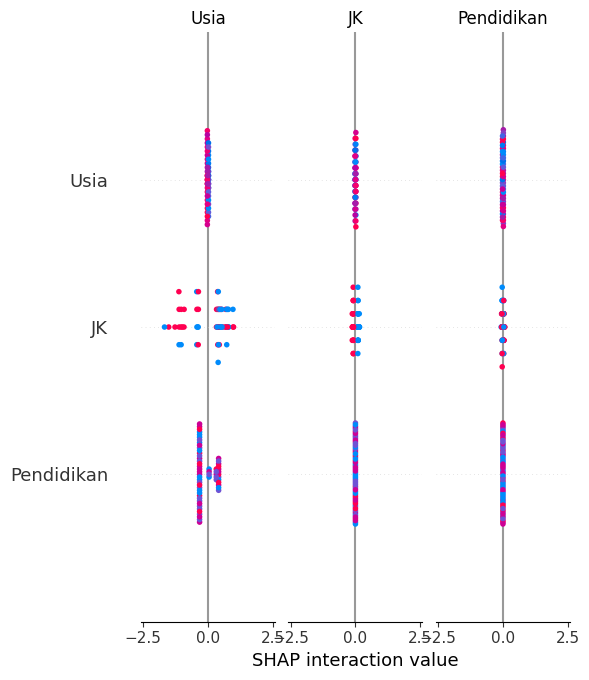

In [ ]:
shap.summary_plot(

    shap_values,

    X_test

)

In [ ]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':model.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

importance.head(10)

,Feature,Importance
4,Persentase nilai identifikasi warna,0.297442
6,Kemampuan identifikasi Warna,0.129638
17,ColorReq,0.112998
5,Tingkat Keparahan,0.111914
16,JobZone,0.057304
15,Karier,0.050887
9,A,0.037016
0,Usia,0.030148
1,JK,0.028340
12,C,0.021913


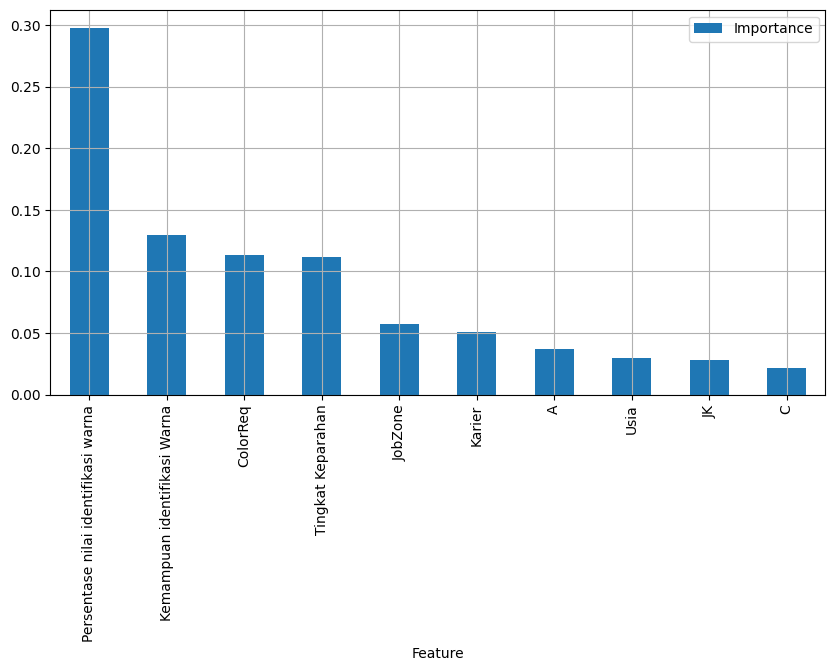

In [ ]:
importance.head(10).plot(

    kind='bar',

    x='Feature',

    y='Importance',

    figsize=(10,5)

)

plt.grid()

plt.show()

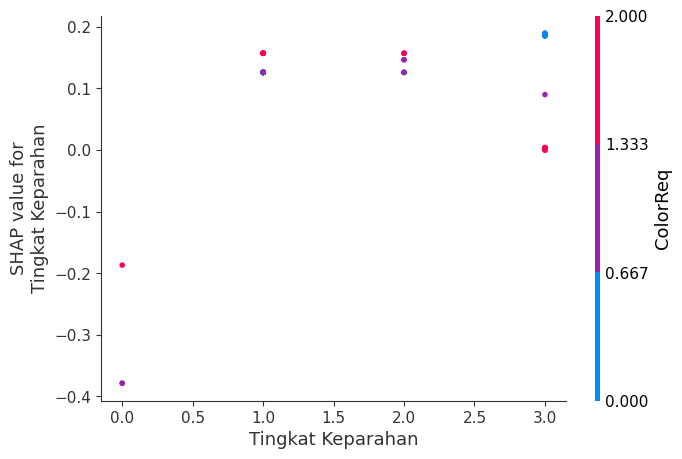

In [ ]:
shap.dependence_plot(
    "Tingkat Keparahan",
    # Select the SHAP values for the first class (index 0)
    # The target_encoder.classes_ are ['Direkomendasikan', 'Kurang Direkomendasikan', 'Tidak Direkomendasikan']
    # so this plots for 'Direkomendasikan'
    shap_values[:, :, 0],
    X_test
)

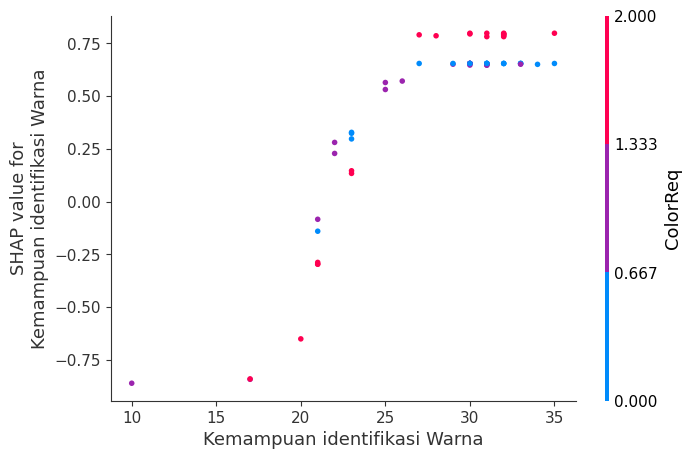

In [ ]:
shap.dependence_plot(
    "Kemampuan identifikasi Warna",
    # Select the SHAP values for the first class (index 0)
    # The target_encoder.classes_ are ['Direkomendasikan', 'Kurang Direkomendasikan', 'Tidak Direkomendasikan']
    # so this plots for 'Direkomendasikan'
    shap_values[:, :, 0],
    X_test
)

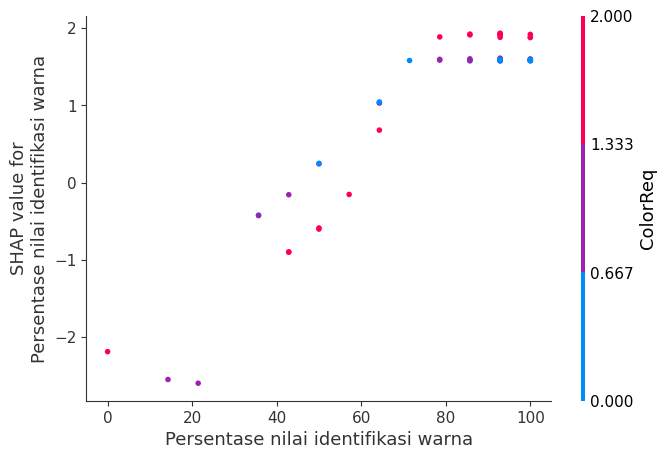

In [ ]:
shap.dependence_plot(
    "Persentase nilai identifikasi warna",
    # Select the SHAP values for the first class (index 0)
    # The target_encoder.classes_ are ['Direkomendasikan', 'Kurang Direkomendasikan', 'Tidak Direkomendasikan']
    # so this plots for 'Direkomendasikan'
    shap_values[:, :, 0],
    X_test
)